In [1]:
# Web Analytics: Product graph and PageRank
# Dataset: amazon.csv

import pandas as pd
import networkx as nx
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('amazon.csv')
df.head

<bound method NDFrame.head of       product_id                                       product_name  \
0     B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1     B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2     B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3     B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4     B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   
...          ...                                                ...   
1460  B08L7J3T31  Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...   
1461  B01M6453MB  Prestige Delight PRWO Electric Rice Cooker (1 ...   
1462  B009P2LIL4  Bajaj Majesty RX10 2000 Watts Heat Convector R...   
1463  B00J5DYCCA  Havells Ventil Air DSP 230mm Exhaust Fan (Pist...   
1464  B01486F4G6  Borosil Jumbo 1000-Watt Grill Sandwich Maker (...   

                                               category discounted_price  \
0     Computers&Accessories|Accessories&P

In [2]:
# Build user -> products mapping (products reviewed by the same user)
# user_id column can contain multiple comma-separated IDs per row
user_products = defaultdict(set)
for _, row in df.iterrows():
    pid = row['product_id']
    uids = str(row['user_id']).strip().split(',')
    for uid in uids:
        uid = uid.strip()
        if uid and uid.lower() != 'nan':
            user_products[uid].add(pid)

# Drop users with only one product (no co-occurrence)
user_products = {u: prods for u, prods in user_products.items() if len(prods) >= 2}
print('Users with 2+ products reviewed:', len(user_products))

Users with 2+ products reviewed: 911


In [3]:
# Count co-reviews: weight = number of users who reviewed both products
from itertools import combinations
edge_counts = defaultdict(int)
for prods in user_products.values():
    for p1, p2 in combinations(prods, 2):
        if p1 != p2:
            key = (min(p1, p2), max(p1, p2))
            edge_counts[key] += 1

print('Number of product-pair edges:', len(edge_counts))
print('Sample edges (product pair -> count):', list(edge_counts.items())[:5])

Number of product-pair edges: 652
Sample edges (product pair -> count): [(('B07JGDB5M1', 'B07JH1C41D'), 8), (('B07JGDB5M1', 'B07JH1CBGW'), 8), (('B07JGDB5M1', 'B07JW9H4J1'), 8), (('B07JGDB5M1', 'B07JW1Y6XV'), 8), (('B07JGDB5M1', 'B07LGT55SJ'), 8)]


In [4]:
# Build undirected weighted graph and run PageRank
G = nx.Graph()
for (p1, p2), w in edge_counts.items():
    G.add_edge(p1, p2, weight=w)

print('Nodes:', G.number_of_nodes(), 'Edges:', G.number_of_edges())

# PageRank using edge weights (more co-reviews = stronger link)
pagerank = nx.pagerank(G, weight='weight')
# Sort by PageRank
pr_sorted = sorted(pagerank.items(), key=lambda x: -x[1])
print('\nTop 15 products by PageRank:')
for i, (pid, pr) in enumerate(pr_sorted[:15], 1):
    name = df.loc[df['product_id']==pid, 'product_name'].iloc[0] if pid in df['product_id'].values else pid
    if isinstance(name, str) and len(name) > 60:
        name = name[:57] + '...'
    print(f'{i:2}. {pid}  PR={pr:.6f}  {name}')

Nodes: 570 Edges: 652

Top 15 products by PageRank:
 1. B0711PVX6Z  PR=0.003977  AmazonBasics Micro USB Fast Charging Cable for Android Ph...
 2. B07232M876  PR=0.003977  Amazonbasics Micro Usb Fast Charging Cable For Android Sm...
 3. B01M4GGIVU  PR=0.003715  Tizum High Speed HDMI Cable with Ethernet | Supports 3D 4...
 4. B01M5967SY  PR=0.003715  TIZUM High Speed HDMI Cable Aura -Gold Plated-High Speed ...
 5. B09YLX91QR  PR=0.003625  Ambrane 60W / 3A Fast Charging Output Cable with Type-C t...
 6. B09YLXYP7Y  PR=0.003625  Ambrane 60W / 3A Fast Charging Output Cable with Type-C t...
 7. B09YLYB9PB  PR=0.003625  Ambrane 60W / 3A Fast Charging Output Cable with Micro to...
 8. B0993BB11X  PR=0.003352  Ambrane 10000mAh Slim Power Bank, 20W Fast Charging, Dual...
 9. B09MZCQYHZ  PR=0.003352  Ambrane 10000mAh Slim Power Bank, 20W Fast Charging, Dual...
10. B01HJI0FS2  PR=0.003302  Dell MS116 1000Dpi USB Wired Optical Mouse, Led Tracking,...
11. B08WJ86PV2  PR=0.003144  RPM Euro Games Gami

In [5]:
# Optional: "Bait" signal — high PageRank but low review activity (influential but under-reviewed)
# Use rating_count as a proxy for sales/review volume (may need to clean numeric)
def safe_rating_count(val):
    try:
        s = str(val).replace(',', '')
        return int(s) if s.isdigit() else 0
    except Exception:
        return 0

df['rc'] = df['rating_count'].apply(safe_rating_count)
sales_like = df.groupby('product_id')['rc'].max().to_dict()
pr_df = pd.DataFrame([(p, pr, sales_like.get(p, 0)) for p, pr in pr_sorted],
                     columns=['product_id', 'pagerank', 'review_count'])
pr_df['pr_rank'] = pr_df['pagerank'].rank(ascending=False)
pr_df['rc_rank'] = pr_df['review_count'].rank(ascending=False)
# Bait-like: high PR rank, low RC rank
pr_df['bait_score'] = pr_df['pr_rank'] - pr_df['rc_rank']  # positive = more influential than "sales"
bait_candidates = pr_df.nlargest(10, 'bait_score')
print('Top 10 bait-like products (high PageRank, low review count):')
display(bait_candidates.merge(df[['product_id','product_name','category']].drop_duplicates(), on='product_id', how='left'))

Top 10 bait-like products (high PageRank, low review count):


,product_id,pagerank,review_count,pr_rank,rc_rank,bait_score,product_name,category
0,B01MF8MB65,0.000695,273189,546.5,11.0,535.5,boAt Bassheads 225 in Ear Wired Earphones with...,"Electronics|Headphones,Earbuds&Accessories|Hea..."
1,B07TCN5VR9,0.000833,77027,529.0,50.0,479.0,Boult Audio BassBuds X1 in-Ear Wired Earphones...,"Electronics|Headphones,Earbuds&Accessories|Hea..."
2,B07CD2BN46,0.001222,119466,496.0,34.0,462.0,Xiaomi Mi Wired in Ear Earphones with Mic Basi...,"Electronics|Headphones,Earbuds&Accessories|Hea..."
3,B09X7DY7Q4,0.001346,205052,473.5,12.0,461.5,SanDisk Extreme SD UHS I 64GB Card for 4K Vide...,Electronics|Accessories|MemoryCards|MicroSD
4,B07S851WX5,0.000695,40106,546.5,86.0,460.5,"Prestige Sandwich Maker PGMFD 01, Black",Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...
5,B076B8G5D8,0.001021,68664,514.0,56.0,458.0,Boya ByM1 Auxiliary Omnidirectional Lavalier C...,MusicalInstruments|Microphones|Condenser
6,B09FKDH6FS,0.000585,30907,560.0,114.0,446.0,"realme narzo 50i (Mint Green, 2GB RAM+32GB Sto...",Electronics|Mobiles&Accessories|Smartphones&Ba...
7,B01M72LILF,0.000709,34852,540.0,96.0,444.0,"Logitech M221 Wireless Mouse, Silent Buttons, ...",Computers&Accessories|Accessories&Peripherals|...
8,B07VQGVL68,0.001063,44994,511.5,79.0,432.5,Glun Multipurpose Portable Electronic Digital ...,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...
9,B07DJLFMPS,0.000725,32625,537.0,107.0,430.0,HP 32GB Class 10 MicroSD Memory Card (U1 TF Ca...,Electronics|Accessories|MemoryCards|MicroSD


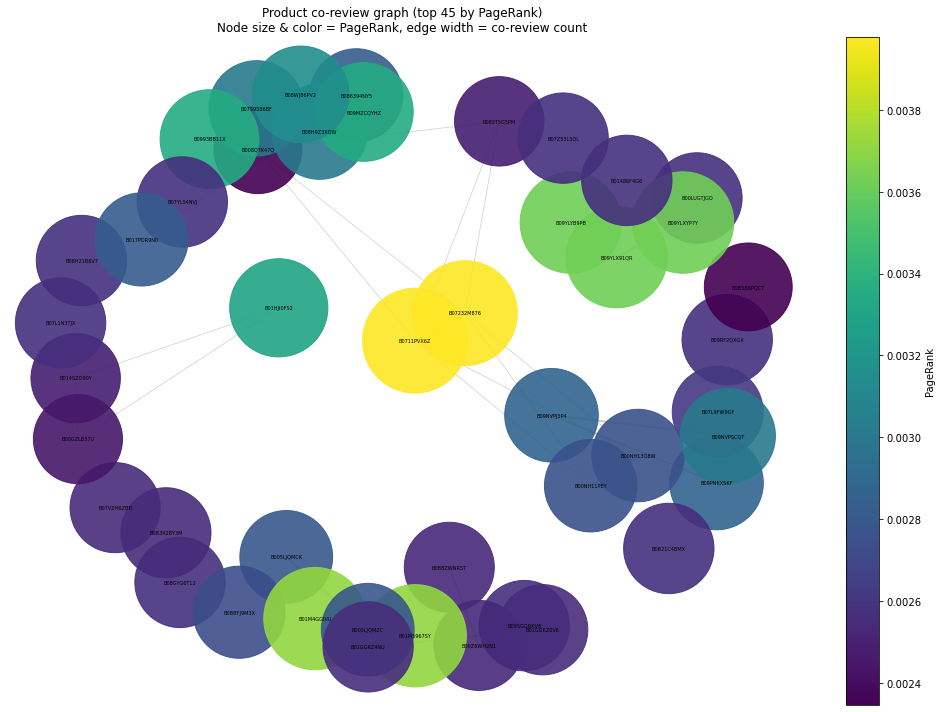

In [6]:
# Draw the product graph (subgraph = top 45 nodes by PageRank for readability)
import matplotlib.pyplot as plt

top_n = 45
top_nodes = [pid for pid, _ in pr_sorted[:top_n]]
H = G.subgraph(top_nodes)
pos = nx.spring_layout(H, k=1.2, seed=42, iterations=50)
pr_sub = {n: pagerank[n] for n in H.nodes()}
sizes = [3000 + 8000 * pr_sub[n] / max(pr_sub.values()) for n in H.nodes()]
max_w = max(H.edges[e].get('weight', 1) for e in H.edges()) or 1
widths = [0.5 + 1.5 * H.edges[u, v].get('weight', 1) / max_w for u, v in H.edges()]

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_edges(H, pos, width=widths, alpha=0.4, edge_color='gray', ax=ax)
nx.draw_networkx_nodes(H, pos, node_size=sizes, node_color=list(pr_sub.values()),
                      cmap=plt.cm.viridis, alpha=0.9, ax=ax)
nx.draw_networkx_labels(H, pos, {n: n for n in H.nodes()}, font_size=5, ax=ax)
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(min(pr_sub.values()), max(pr_sub.values())))
plt.colorbar(sm, ax=ax, label='PageRank')
ax.set_title('Product co-review graph (top 45 by PageRank)\nNode size & color = PageRank, edge width = co-review count')
ax.axis('off')
plt.tight_layout()
plt.show()

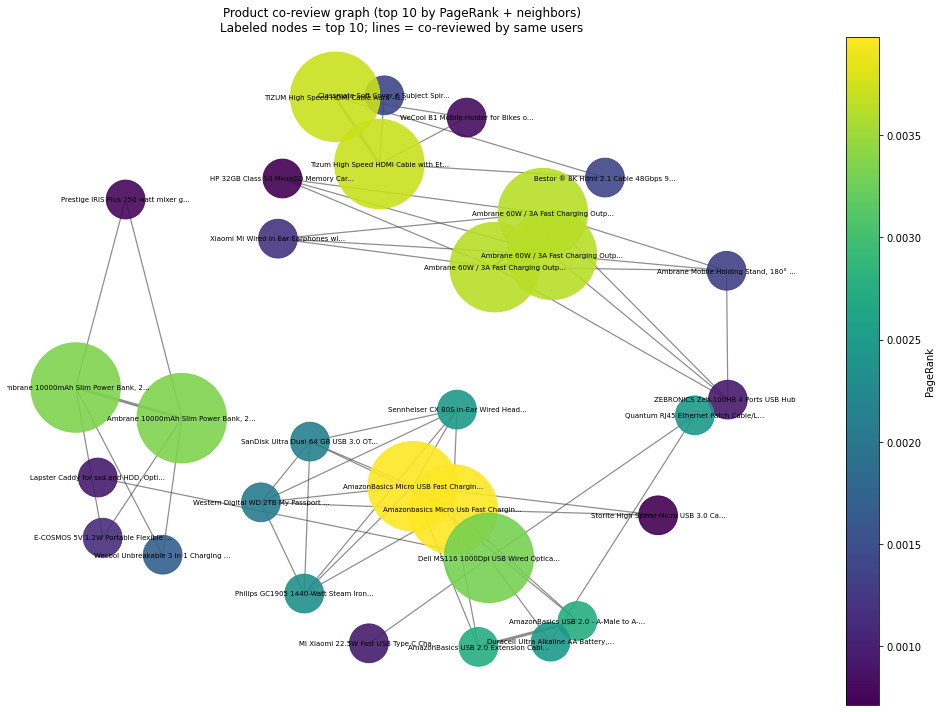

In [7]:
# Same graph with product names (top n + their neighbors so edges show)
top_n = 10
top_nodes = [pid for pid, _ in pr_sorted[:top_n]]
# Include neighbors so there are edges between top-25 and others (induced subgraph on top-25 alone often has no edges)
neighbors = set()
for n in top_nodes:
    neighbors.update(G.neighbors(n))
neighbors -= set(top_nodes)
subgraph_nodes = set(top_nodes) | neighbors
H2 = G.subgraph(subgraph_nodes)

pos2 = nx.spring_layout(H2, k=1.2, seed=42, iterations=50)
pr_sub2 = {n: pagerank[n] for n in H2.nodes()}
# Top-25 nodes larger, neighbors smaller
top_set = set(top_nodes)
sizes2 = [8000 if n in top_set else 1500 for n in H2.nodes()]
max_w2 = max(H2.edges[e].get('weight', 1) for e in H2.edges()) or 1
widths2 = [1.0 + 2.0 * H2.edges[u, v].get('weight', 1) / max_w2 for u, v in H2.edges()]

def get_name(pid, max_len=35):
    row = df[df['product_id'] == pid]
    if row.empty:
        return pid
    name = str(row['product_name'].iloc[0]).strip()
    return name[:max_len] + '...' if len(name) > max_len else name
# Label every node with product name
labels2 = {n: get_name(n) for n in H2.nodes()}

fig2, ax2 = plt.subplots(figsize=(14, 10))
nx.draw_networkx_edges(H2, pos2, width=widths2, alpha=0.6, edge_color='#444', ax=ax2)
nx.draw_networkx_nodes(H2, pos2, node_size=sizes2, node_color=list(pr_sub2.values()),
                      cmap=plt.cm.viridis, alpha=0.9, ax=ax2)
nx.draw_networkx_labels(H2, pos2, labels2, font_size=7, ax=ax2)
sm2 = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(min(pr_sub2.values()), max(pr_sub2.values())))
plt.colorbar(sm2, ax=ax2, label='PageRank')
ax2.set_title('Product co-review graph (top 10 by PageRank + neighbors)\nLabeled nodes = top 10; lines = co-reviewed by same users')
ax2.axis('off')
plt.tight_layout()
plt.show()

## Findings
1. What We Know So Far: we drew a “map” of your products

Each dot is one product (e.g. a cable, a power bank, earphones).
We drew a line between two dots when “the same person reviewed both of those products.”
So the lines show: “these products tend to be seen (or compared) by the same customers.”
That’s the “graph”: dots = products, lines = “reviewed together by the same people.” No math needed for that idea—it’s just a map of relationships.

2. What the lines mean

More lines from a product = that product often appears in the same basket of reviews as many others.
So it’s “in the middle of the action”—people who look at one thing often also look at this one.
Thicker lines = that pair of products is co‑reviewed by more people (stronger link).
So: dots = products, lines = “customers often look at these two together.”

3. What “PageRank” is

We then asked a simple question: Which products are “in the middle” of this map?
Not just “how many lines do I have?” but “how connected am I to other products that are themselves very connected?”
A product gets a high score (what we call PageRank) if:

It’s reviewed together with many other products, and
Those other products are also well connected.
So the score is a measure of “how central or important this product is in the network of ‘who gets reviewed with whom.’”
We don’t have to call it “PageRank”; we can just say: “importance in the co‑review network.”

4. What the findings mean

Big, bright dots (high score)
= Products that sit in the “center” of customer behavior: lots of people who look at other things also look at these. They’re hubs in the map.

High score but few reviews (“bait-like” products)
= Products that don’t get many reviews on their own, but they’re strongly tied to products that do get a lot of attention.
So: “People don’t review this one much, but they often see it when they’re looking at popular stuff.”
In business terms: don’t drop these just because they don’t sell a lot—they may be helping other products get seen and sold.

Low score, few reviews
= Off to the side of the map, and not many people review them.
Those are the ones you might consider dropping (after checking seasonality, etc.).

## Findings Summary:
We drew a map of which products get reviewed together, measured which ones are ‘in the center’ of that map (that’s the score), and used that to see which products are important for the rest—even if they don’t sell much themselves.

### Other Graph Algorithms

In [9]:
!pip install python-louvain

     |████████████████████████████████| 204 kB 20.4 MB/s eta 0:00:01
  Created wheel for python-louvain: filename=python_louvain-0.16-py3-none-any.whl size=9407 sha256=92cea462abaac1e7a474aafcf5683afec173299fb03108e46ad85656c718be06
  Stored in directory: /root/.cache/pip/wheels/4d/7c/b6/79b198e4ec43f915fbdf967953d48b89a18893b12aa9df0ae2
Successfully built python-louvain


In [14]:
# Community Detection Algorithm
import community as community_louvain
partition = community_louvain.best_partition(G)

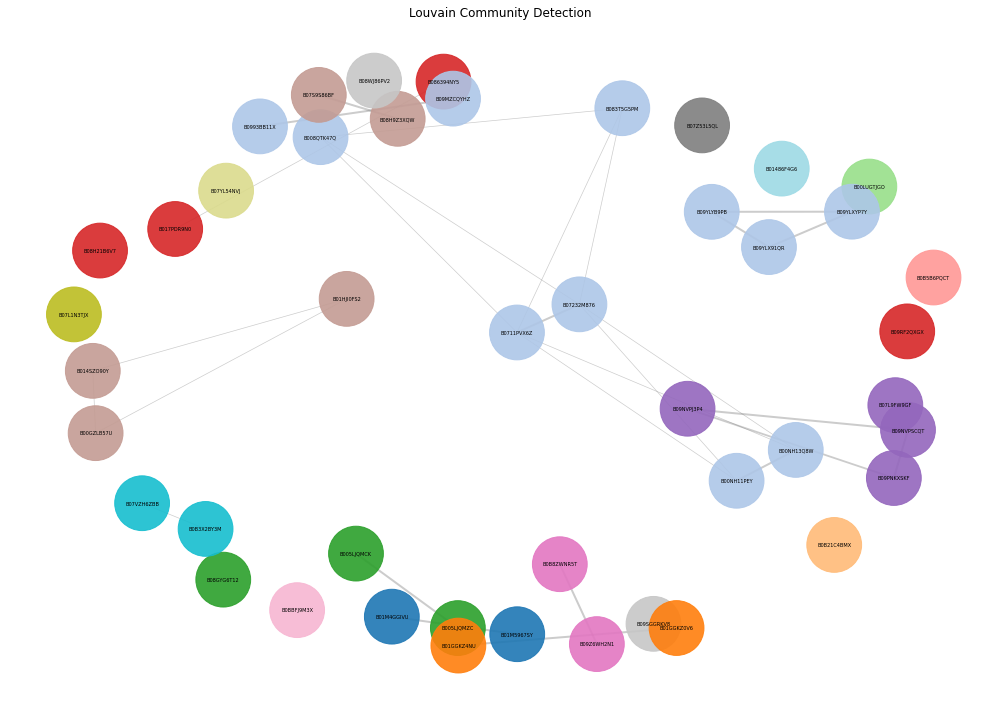

In [18]:
# Community Detection Visualization
top_n = 45
top_nodes = [pid for pid, _ in pr_sorted[:top_n]]
H = G.subgraph(top_nodes)

pos = nx.spring_layout(H, k=1.2, seed=42, iterations=50)

# Color by community
colors = [partition[n] for n in H.nodes()]

max_w = max(H.edges[e].get('weight', 1) for e in H.edges()) or 1
widths = [0.5 + 1.5 * H.edges[u, v].get('weight', 1) / max_w for u, v in H.edges()]

fig, ax = plt.subplots(figsize=(14,10))
nx.draw_networkx_edges(H, pos, width=widths, alpha=0.4, edge_color='gray', ax=ax)
nx.draw_networkx_nodes(H, pos,
                      node_size=3000,
                      node_color=colors,
                      cmap=plt.cm.tab20,
                      alpha=0.9,
                      ax=ax)
nx.draw_networkx_labels(H, pos, {n: n for n in H.nodes()}, font_size=5, ax=ax)

ax.set_title('Louvain Community Detection')
ax.axis('off')
plt.tight_layout()
plt.show()

In [12]:
# Degree Centrality Algorithm
degree_centrality = nx.degree_centrality(G)

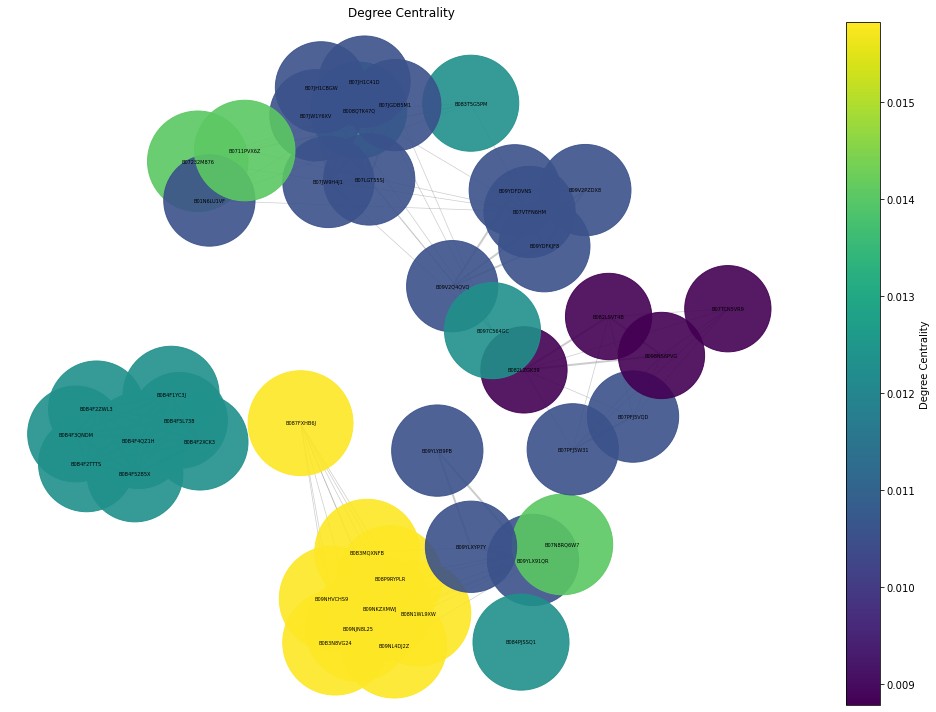

In [23]:
top_n = 45
top_nodes = sorted(degree_centrality, key=degree_centrality.get, reverse=True)[:top_n]
H = G.subgraph(top_nodes)

pos = nx.spring_layout(H, k=1.2, seed=42, iterations=50)

dc_sub = {n: degree_centrality[n] for n in H.nodes()}

sizes = [3000 + 8000 * dc_sub[n] / max(dc_sub.values()) for n in H.nodes()]

max_w = max(H.edges[e].get('weight', 1) for e in H.edges()) or 1
widths = [0.5 + 1.5 * H.edges[u, v].get('weight', 1) / max_w for u, v in H.edges()]

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_edges(H, pos, width=widths, alpha=0.4, edge_color='gray', ax=ax)
nx.draw_networkx_nodes(H, pos,
                      node_size=sizes,
                      node_color=list(dc_sub.values()),
                      cmap=plt.cm.viridis,
                      alpha=0.9,
                      ax=ax)
nx.draw_networkx_labels(H, pos, {n: n for n in H.nodes()}, font_size=5, ax=ax)

sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(min(dc_sub.values()), max(dc_sub.values())))

plt.colorbar(sm, ax=ax, label='Degree Centrality')

ax.set_title('Degree Centrality')
ax.axis('off')
plt.tight_layout()
plt.show()

In [13]:
# Betweenness Centrality Algorithm
betweenness_centrality = nx.betweenness_centrality(G, weight='weight')

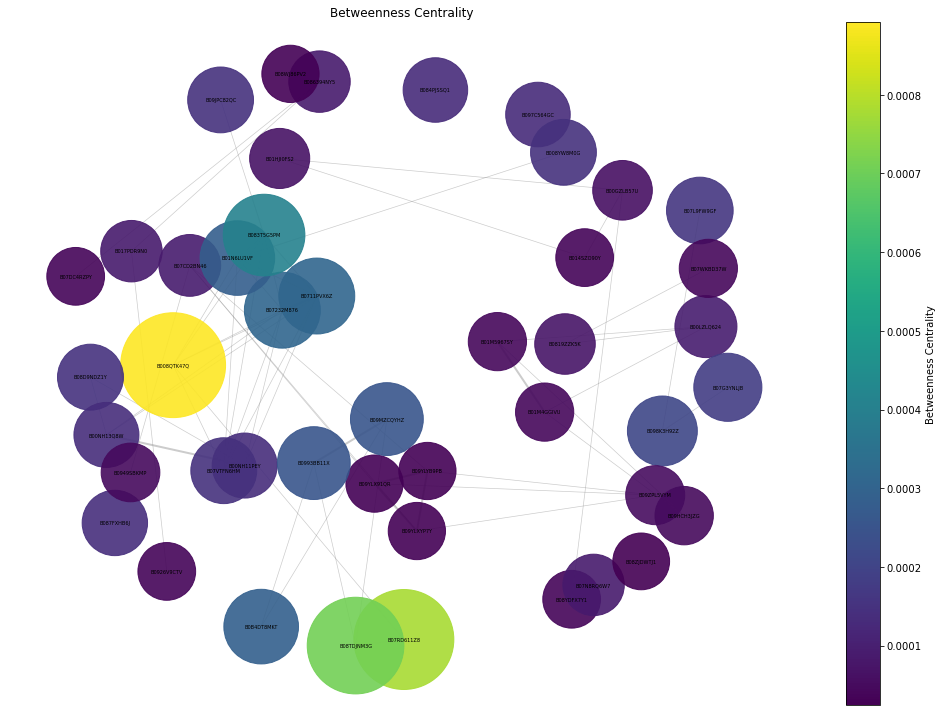

In [25]:
top_n = 45
top_nodes = sorted(betweenness_centrality, key=betweenness_centrality.get, reverse=True)[:top_n]
H = G.subgraph(top_nodes)

pos = nx.spring_layout(H, k=1.2, seed=42, iterations=50)

bt_sub = {n: betweenness_centrality[n] for n in H.nodes()}

sizes = [3000 + 8000 * bt_sub[n] / max(bt_sub.values()) for n in H.nodes()]

max_w = max(H.edges[e].get('weight', 1) for e in H.edges()) or 1
widths = [0.5 + 1.5 * H.edges[u, v].get('weight', 1) / max_w for u, v in H.edges()]

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_edges(H, pos, width=widths, alpha=0.4, edge_color='gray', ax=ax)
nx.draw_networkx_nodes(H, pos,
                      node_size=sizes,
                      node_color=list(bt_sub.values()),
                      cmap=plt.cm.viridis,
                      alpha=0.9,
                      ax=ax)
nx.draw_networkx_labels(H, pos, {n: n for n in H.nodes()}, font_size=5, ax=ax)

sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis,
                          norm=plt.Normalize(min(bt_sub.values()), max(bt_sub.values())))
plt.colorbar(sm, ax=ax, label='Betweenness Centrality')

ax.set_title('Betweenness Centrality')
ax.axis('off')
plt.tight_layout()
plt.show()